# Previsão de Tempo de Entrega — Olist (FastAPI + Docker)

Estima em **quantos dias** um pedido será entregue, a partir de características do pedido. O destaque do projeto é a cadeia completa: **dado → modelo → API → container**. Aqui mostramos a parte de dados e modelagem; a lógica vive em `src/`.

## 0. Setup

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd()
if not (RAIZ / 'src').exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import pandas as pd

from src.data import juntar_tabelas
from src.features import construir_dataset

FIG = RAIZ / 'reports' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
ds = construir_dataset(juntar_tabelas(RAIZ / 'data'))
print(f'{len(ds):,} pedidos entregues (após limpeza)')
ds[['delivery_days', 'freight_value', 'product_weight_g', 'same_state']].describe().round(2)

96,406 pedidos entregues (após limpeza)


,delivery_days,freight_value,product_weight_g,same_state
count,96406.00,96406.00,96406.00,96406.00
mean,12.47,22.78,2386.21,0.36
std,8.88,21.56,4769.80,0.48
min,0.53,0.00,0.00,0.00
25%,6.76,13.85,300.00,0.00
50%,10.21,17.17,750.00,0.00
75%,15.70,24.01,2050.00,1.00
max,99.95,1794.96,184400.00,1.00


## 1. EDA

### 1.1 Distribuição do tempo de entrega
A maioria entrega em ~1-2 semanas, mas há uma cauda longa.

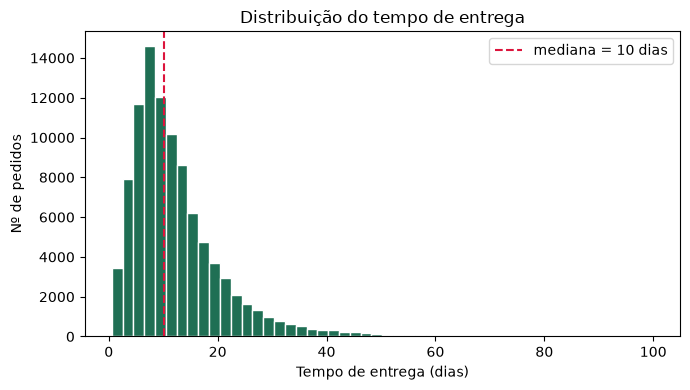

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ds.delivery_days, bins=50, color='#1f6f54', edgecolor='white')
ax.axvline(ds.delivery_days.median(), color='crimson', linestyle='--',
           label=f'mediana = {ds.delivery_days.median():.0f} dias')
ax.set_xlabel('Tempo de entrega (dias)'); ax.set_ylabel('Nº de pedidos')
ax.set_title('Distribuição do tempo de entrega'); ax.legend()
fig.tight_layout(); fig.savefig(FIG / 'dist_entrega.png', dpi=120); plt.show()

### 1.2 Mesma UF vs. UFs diferentes
A distância importa: pedidos em que cliente e vendedor estão no **mesmo estado** chegam bem mais rápido.

              mean  median  count
UF diferente  15.0    12.8  61716
Mesma UF       7.9     6.5  34690


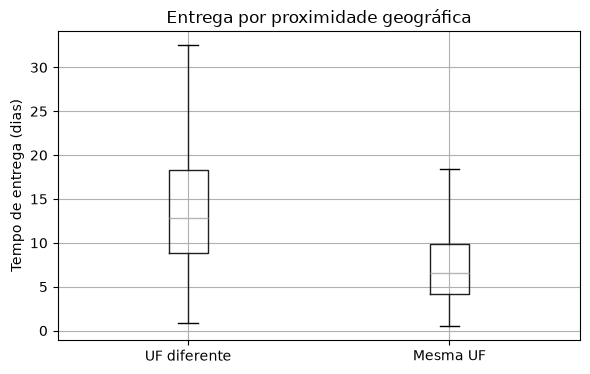

In [3]:
por_uf = ds.groupby('same_state').delivery_days.agg(['mean', 'median', 'count'])
por_uf.index = ['UF diferente', 'Mesma UF']
print(por_uf.round(1))
fig, ax = plt.subplots(figsize=(6, 4))
ds.boxplot(column='delivery_days', by='same_state', ax=ax, showfliers=False)
ax.set_xticklabels(['UF diferente', 'Mesma UF'])
ax.set_xlabel(''); ax.set_ylabel('Tempo de entrega (dias)')
ax.set_title('Entrega por proximidade geográfica'); plt.suptitle('')
fig.tight_layout(); fig.savefig(FIG / 'entrega_por_uf.png', dpi=120); plt.show()

### 1.3 Relação com o frete
Frete mais alto tende a acompanhar entregas mais longas (proxy de distância/peso).

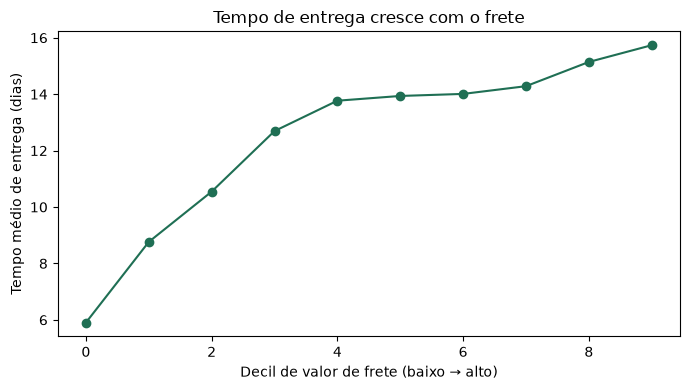

In [4]:
faixas = pd.qcut(ds.freight_value, 10, duplicates='drop')
media = ds.groupby(faixas, observed=True).delivery_days.mean()
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(media)), media.values, marker='o', color='#1f6f54')
ax.set_xlabel('Decil de valor de frete (baixo → alto)')
ax.set_ylabel('Tempo médio de entrega (dias)')
ax.set_title('Tempo de entrega cresce com o frete')
fig.tight_layout(); fig.savefig(FIG / 'entrega_vs_frete.png', dpi=120); plt.show()

## 2. Modelagem

Pipeline do pacote (`src/train.py`): one-hot dos estados + Gradient Boosting, comparado ao baseline (prever a média). Métrica em **dias**. Salva o modelo em `models/` para a API.

In [5]:
from src.train import main as treinar
res = treinar()
pd.DataFrame({
    'Baseline (média)': {'MAE': res['baseline_mae']},
    'Gradient Boosting': {'MAE': res['mae'], 'RMSE': res['rmse']},
}).T.round(2)

Pedidos após limpeza: 96406
Baseline (média=12.4d)   MAE=6.43  RMSE=9.21  (dias)


Gradient Boosting           MAE=4.94  RMSE=7.58  (dias)


Modelo salvo em /home/david-alves-de-oliveira/Documentos/TI/git/projeto 6 /previsao-entrega-logistica/models/modelo.joblib


,MAE,RMSE
Baseline (média),6.43,NaN
Gradient Boosting,4.94,7.58


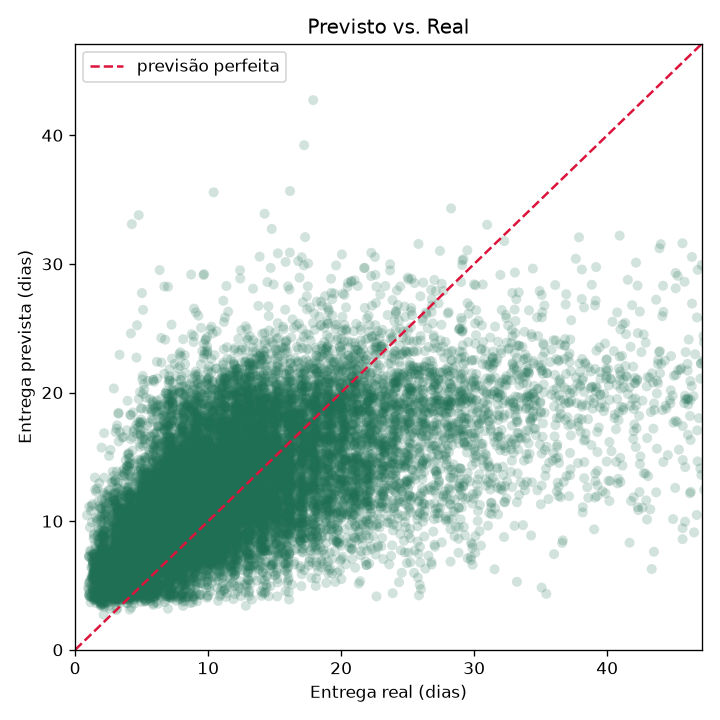

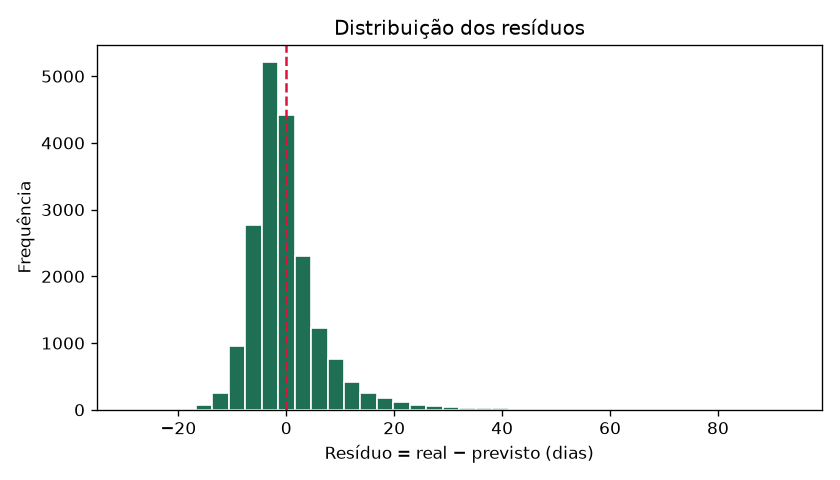

In [6]:
from IPython.display import Image, display
for nome in ['previsto_vs_real.png', 'residuos.png']:
    display(Image(filename=str(FIG / nome)))

## 3. Conclusão

- O modelo erra **~5 dias (MAE)**, contra ~6,4 do baseline — ganho real usando frete, peso/volume, nº de itens, proximidade (mesma UF) e sazonalidade da compra.
- O **Pipeline completo** (pré-processamento + modelo) é salvo em `models/modelo.joblib` e servido pela **API FastAPI** (`api/main.py`), empacotada em **Docker**.
- Todos os números vêm desta execução real.